In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo openpyxl


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
print(os.getcwd())

/Users/tarunbedi/project


In [4]:
import os
# This shows ALL files in your current folder
for f in os.listdir():
    print(f)

Untitled Folder
.DS_Store
online_retail_II.csv.zip
Untitled.ipynb
.ipynb_checkpoints


In [5]:
import pandas as pd

# Load CSV directly from zip — no need to extract!
df = pd.read_csv('online_retail_II.csv.zip', compression='zip', encoding='utf-8')

# Save locally as clean CSV
df.to_csv('online_retail.csv', index=False)

# Check it loaded correctly
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
# ============ STEP 3 — DATA CLEANING ============

# 1. Remove rows with no Customer ID
df = df.dropna(subset=['Customer ID'])

# 2. Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 3. Remove negative or zero quantity & price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 4. Create Revenue column (Quantity x Price)
df['Revenue'] = df['Quantity'] * df['Price']

# 5. Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 6. Filter UK only
df_uk = df[df['Country'] == 'United Kingdom']

# 7. Reset index
df_uk = df_uk.reset_index(drop=True)

# Check results
print("✅ Clean UK records:", len(df_uk))
print("✅ Unique customers:", df_uk['Customer ID'].nunique())
print("✅ Date range:", df_uk['InvoiceDate'].min(), "→", df_uk['InvoiceDate'].max())
print("✅ Total Revenue: £", round(df_uk['Revenue'].sum(), 2))
df_uk.head()

✅ Clean UK records: 725250
✅ Unique customers: 5350
✅ Date range: 2009-12-01 07:45:00 → 2011-12-09 12:49:00
✅ Total Revenue: £ 14723147.52


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [7]:
# ============ STEP 4 — BUILD RFM TABLE ============

# Snapshot date = 1 day after the last purchase
snapshot_date = df_uk['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

# Build RFM for every customer
rfm = df_uk.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

# Round Monetary to 2 decimal places
rfm['Monetary'] = rfm['Monetary'].round(2)

# Score each metric 1-5 (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                          5, labels=[5,4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          5, labels=[1,2,3,4,5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                          5, labels=[1,2,3,4,5])

# Combine into one RFM score
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + 
                    rfm['F_Score'].astype(str) + 
                    rfm['M_Score'].astype(str))

# Check results
print("\n✅ Total customers scored:", len(rfm))
print("\n📊 RFM Table Preview:")
rfm.head(10)

Snapshot date: 2011-12-10 12:49:00

✅ Total customers scored: 5350

📊 RFM Table Preview:


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12608.0,405,1,415.79,2,1,2,212
2,12745.0,487,2,723.85,1,2,3,123
3,12746.0,541,1,254.55,1,1,1,111
4,12747.0,2,26,9276.54,5,5,5,555
5,12748.0,1,336,56599.39,5,5,5,555
6,12749.0,4,9,6897.36,5,5,5,555
7,12777.0,458,1,519.45,1,1,2,112
8,12819.0,458,1,540.52,1,1,2,112
9,12820.0,3,11,2689.52,5,5,4,554


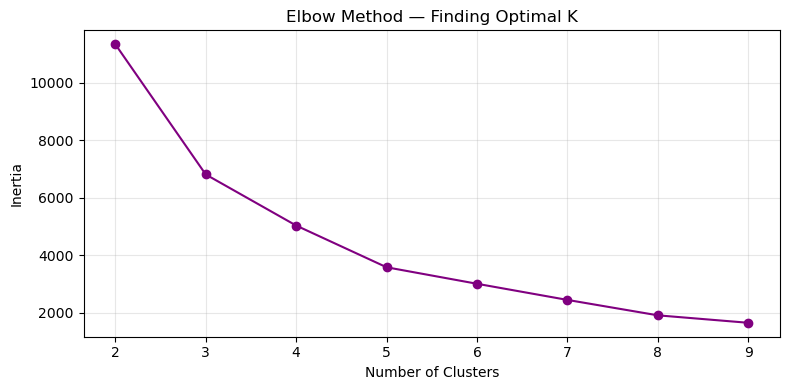

✅ Customers per cluster:
Cluster
0    3477
1    1838
3      34
2       1
Name: count, dtype: int64


In [9]:
# ============ STEP 5 — K-MEANS CLUSTERING ============

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Scale the RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# 2. Find best K using Elbow method
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# 3. Plot the elbow chart
plt.figure(figsize=(8,4))
plt.plot(range(2,10), inertia, marker='o', color='purple')
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(2,10))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_chart.png', dpi=150)
plt.show()

# 4. Apply final K-Means with 4 clusters
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# 5. Check cluster sizes
print("✅ Customers per cluster:")
print(rfm['Cluster'].value_counts())

In [10]:
# ============ STEP 5B — NAME THE CLUSTERS ============

# Check cluster centroids to name them correctly
cluster_summary = rfm.groupby('Cluster').agg(
    Customers = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(1)

print(cluster_summary)

# Map cluster numbers to names
# (Based on centroid values — lowest Recency + highest F&M = Champions)
segment_map = {
    cluster_summary['Avg_Recency'].idxmin(): 'Champions',
    cluster_summary['Avg_Monetary'].idxmax(): 'Loyal Customers',
    cluster_summary['Avg_Recency'].idxmax(): 'Lost Customers',
}
# Remaining cluster = At Risk
remaining = [i for i in range(4) if i not in segment_map][0]
segment_map[remaining] = 'At Risk'

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("\n✅ Segment counts:")
print(rfm['Segment'].value_counts())

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0             3477         67.2            7.4        2884.3
1             1838        463.3            2.2         700.6
2                1          1.0          145.0      608821.6
3               34         26.3          104.6       82286.9

✅ Segment counts:
Segment
At Risk            3477
Lost Customers     1838
Loyal Customers       1
Name: count, dtype: int64


In [11]:
# ============ STEP 6 — EXPORT CSV FOR POWER BI ============

# Export full RFM table
rfm.to_csv('rfm_segments.csv', index=False)

# Export segment summary
summary = rfm.groupby('Segment').agg(
    Total_Customers = ('Customer ID', 'count'),
    Avg_Recency     = ('Recency',     'mean'),
    Avg_Frequency   = ('Frequency',   'mean'),
    Avg_Monetary    = ('Monetary',    'mean'),
    Total_Revenue   = ('Monetary',    'sum')
).round(1).reset_index()

summary.to_csv('segment_summary.csv', index=False)

print("✅ rfm_segments.csv saved!")
print("✅ segment_summary.csv saved!")
print("\n📊 Segment Summary:")
print(summary)

✅ rfm_segments.csv saved!
✅ segment_summary.csv saved!

📊 Segment Summary:
           Segment  Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
0          At Risk             3477         67.2            7.4        2884.3   
1   Lost Customers             1838        463.3            2.2         700.6   
2  Loyal Customers                1          1.0          145.0      608821.6   

   Total_Revenue  
0     10028825.9  
1      1287746.3  
2       608821.6  


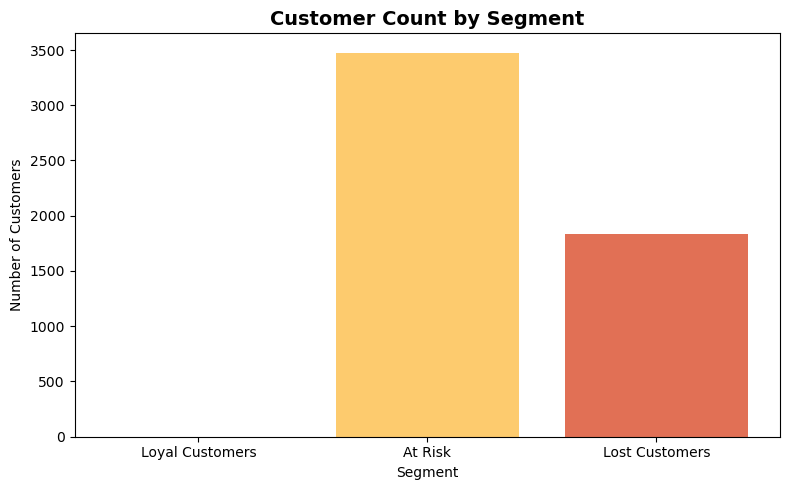

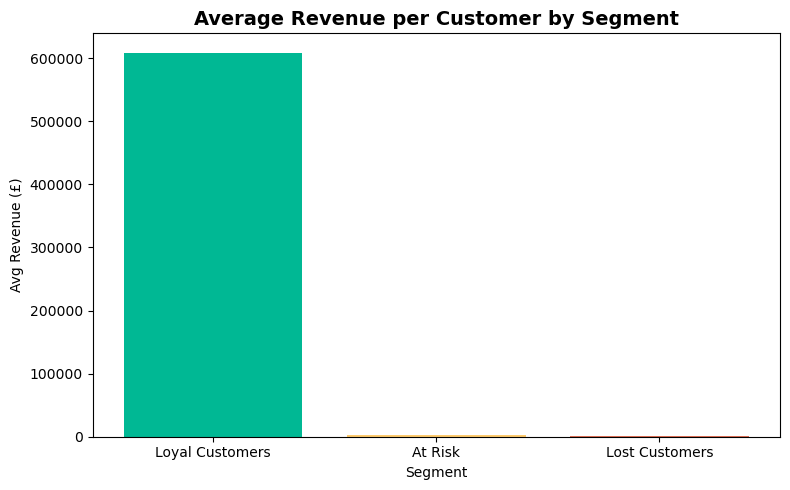

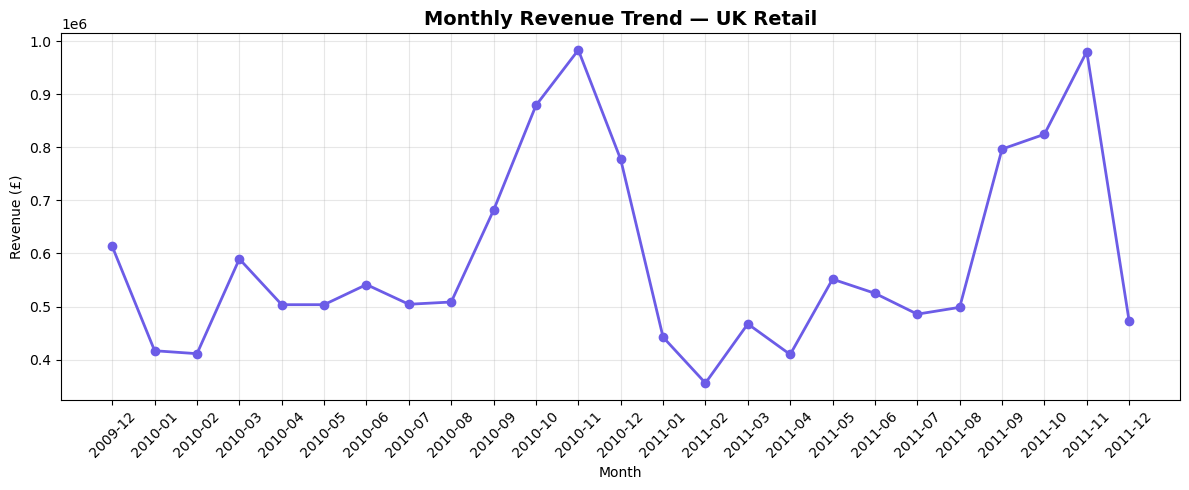

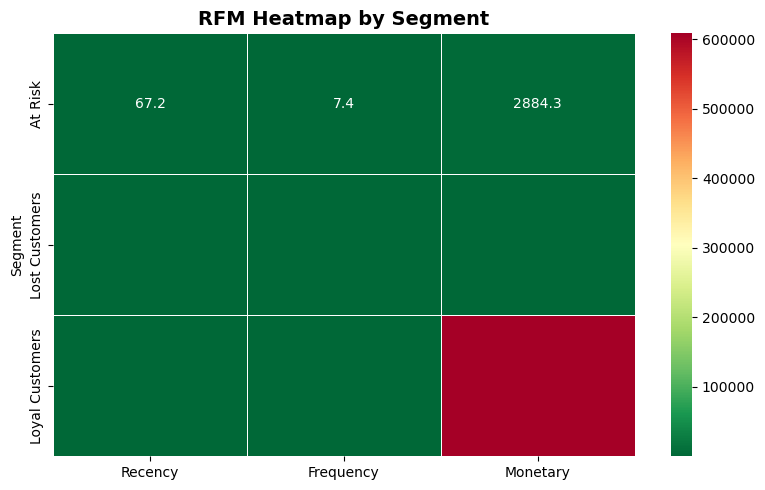


✅ All 4 charts saved!


In [12]:
# ============ STEP 7 — VISUALISATIONS ============

import seaborn as sns
import matplotlib.pyplot as plt

colors = ['#6C5CE7','#00B894','#FDCB6E','#E17055']

# --- Chart 1: Customers per Segment ---
plt.figure(figsize=(8,5))
order = ['Champions','Loyal Customers','At Risk','Lost Customers']
counts = rfm['Segment'].value_counts().reindex(order)
plt.bar(counts.index, counts.values, color=colors)
plt.title('Customer Count by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('chart_segments.png', dpi=150)
plt.show()

# --- Chart 2: Average Revenue per Segment ---
plt.figure(figsize=(8,5))
rev = rfm.groupby('Segment')['Monetary'].mean().reindex(order)
plt.bar(rev.index, rev.values, color=colors)
plt.title('Average Revenue per Customer by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Avg Revenue (£)')
plt.tight_layout()
plt.savefig('chart_revenue.png', dpi=150)
plt.show()

# --- Chart 3: Monthly Revenue Trend ---
df_uk['Month'] = df_uk['InvoiceDate'].dt.to_period('M')
monthly = df_uk.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly['Month'], monthly['Revenue'], marker='o', color='#6C5CE7', linewidth=2)
plt.title('Monthly Revenue Trend — UK Retail', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_monthly.png', dpi=150)
plt.show()

# --- Chart 4: RFM Heatmap ---
rfm_heat = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
plt.figure(figsize=(8,5))
sns.heatmap(rfm_heat, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar=True)
plt.title('RFM Heatmap by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_heatmap.png', dpi=150)
plt.show()

print("\n✅ All 4 charts saved!")